# Thermal Comfort — Algorithm Design (Spiral Approach)
**Notebook 3 of 5**

## Algorithm motivations

### Algorithm 1 — Gaussian Naive Bayes (GNB)
Chosen because:
- It is a direct implementation of Bayesian inference, which the project owner
  explicitly requested (Bayesian analysis of incomplete datasets)
- It models P(TSV | features) via Bayes' theorem, producing probabilistic outputs
  rather than hard decisions — useful for understanding uncertainty
- Computationally lightweight: trains in milliseconds on 70k rows
- Provides a strong interpretable baseline to compare against
- Reference: Zhang et al. (2021) used NB as a baseline in thermal comfort ML work

### Algorithm 2 — Multi-Layer Perceptron (MLP)
Chosen because:
- Thermal comfort involves non-linear interactions (e.g. high temperature
  tolerated at low humidity) that linear models miss
- MLP can learn these interactions through hidden layers
- scikit-learn's MLPClassifier is well-validated and tunable
- Provides contrast to GNB: deep vs shallow, discriminative vs generative
- Reference: Cheung et al. (2019) showed deep models outperform PMV on ASHRAE DB

In [1]:
# =============================================================================
# CELL 2: Imports and load the data split from notebook 02
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle, time, warnings
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
})

DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Load the exact same split saved in NB02
with open(DATA_DIR / 'data_split.pkl', 'rb') as f:
    split = pickle.load(f)

X_train = split['X_train'];  y_train = split['y_train']
X_val   = split['X_val'];    y_val   = split['y_val']
X_test  = split['X_test'];   y_test  = split['y_test']
NUM_COLS = split['num_cols']
CAT_COLS = split['cat_cols']

print("✓ Data split loaded")
print(f"  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"  Numerical features : {NUM_COLS}")
print(f"  Categorical features: {CAT_COLS}")

✓ Data split loaded
  Train: (73117, 9)  Val: (15668, 9)  Test: (15669, 9)
  Numerical features : ['air_temp', 'radiant', 'humidity', 'velocity', 'clothing', 'metabolic']
  Categorical features: ['building', 'climate', 'season']


In [2]:
# =============================================================================
# CELL 3: Build the preprocessing pipeline
#
# ColumnTransformer applies different steps to different column types:
#   - Numerical: fill missing with median, then scale to mean=0 std=1
#   - Categorical: fill missing with most frequent value, then one-hot encode
#
# Using a Pipeline ensures the same transformations apply to train, val, test
# WITHOUT leaking statistics from val/test into training (a common mistake).
# =============================================================================

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,  NUM_COLS),
        ('cat', categorical_transformer, CAT_COLS),
    ],
    remainder='drop'
)

# Fit ONLY on training data, then transform all splits
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

n_features = X_train_proc.shape[1]
print(f"✓ Preprocessing complete")
print(f"  Input features  : {X_train.shape[1]}")
print(f"  After encoding  : {n_features} (categorical columns expanded by OHE)")

✓ Preprocessing complete
  Input features  : 9
  After encoding  : 31 (categorical columns expanded by OHE)


In [3]:
# =============================================================================
# CELL 4: PMV (Predicted Mean Vote) baseline — SP3 requires beating this
#
# PMV formula (Fanger 1970, simplified version):
#   PMV = f(Ta, Tr, Va, RH, MET, CLO)
#   The full equation is complex; we use an approximation from ISO 7730
#   and then round to the nearest integer TSV to get a classification.
#
# This gives us the "traditional physics model" baseline to beat.
# =============================================================================

def pmv_approx(row):
    """
    Simplified PMV approximation (Fanger 1970 / ISO 7730).
    Returns a float in roughly [-3, +3].
    Only runs where all 6 inputs are present.
    """
    Ta  = row.get('air_temp',  22.0)   # Air temperature (°C)
    Tr  = row.get('radiant',   Ta)     # Radiant temp (default = air temp)
    RH  = row.get('humidity',  50.0)   # Relative humidity (%)
    Va  = row.get('velocity',  0.1)    # Air velocity (m/s)
    MET = row.get('metabolic', 1.2)    # Metabolic rate (MET)
    CLO = row.get('clothing',  1.0)    # Clothing insulation (CLO)

    # Operative temperature (simple average of Ta and Tr)
    Top = (Ta + Tr) / 2.0

    # Simplified thermal load (deviation from neutral 22°C operative temp)
    # Full Fanger equation has ~20 terms; this captures the dominant signal
    pmv = (0.303 * np.exp(-0.036 * MET * 58.15) + 0.028) * (
        (MET - 1) * 58.15
        - 3.05e-3 * (5733 - 6.99 * (MET - 1) * 58.15 - RH * 10)
        - 0.42 * ((MET - 1) * 58.15 - 58.15)
        - 1.7e-5 * MET * 58.15 * (5867 - RH * 10)
        - 0.0014 * MET * 58.15 * (34 - Ta)
        - 3.96e-8 * 0.72 * ((Top + 273)**4 - (35.7 - 0.028*(MET-1)*58.15 + 273)**4)
        - 0.72 * Va**0.5 * (34 - Ta)
    )
    return np.clip(pmv, -3, 3)

# Apply PMV to validation set (uses original unscaled data)
val_df = X_val.copy()
val_df['tsv_true'] = y_val.values

pmv_preds_raw = val_df.apply(pmv_approx, axis=1)
pmv_preds = pmv_preds_raw.round().astype(int).clip(-3, 3)

pmv_f1  = f1_score(y_val, pmv_preds, average='weighted', zero_division=0)
pmv_acc = accuracy_score(y_val, pmv_preds)

print("=" * 45)
print("PMV BASELINE (Fanger 1970) — validation set")
print("=" * 45)
print(f"  Weighted F1 : {pmv_f1:.4f}")
print(f"  Accuracy    : {pmv_acc:.4f}  ({pmv_acc*100:.1f}%)")
print(f"\nSP3 target: our ML model must beat F1 = {pmv_f1:.3f}")

PMV BASELINE (Fanger 1970) — validation set
  Weighted F1 : 0.0448
  Accuracy    : 0.1010  (10.1%)

SP3 target: our ML model must beat F1 = 0.045


In [4]:
# =============================================================================
# CELL 5: Algorithm 1 — Gaussian Naive Bayes
#
# GNB assumes each feature is normally distributed within each class.
# It applies Bayes' theorem:
#   P(TSV=k | x) ∝ P(x | TSV=k) × P(TSV=k)
#
# var_smoothing adds a small value to variance — prevents division-by-zero
# when a feature has very low variance for a class.
# =============================================================================

t0 = time.time()

gnb = GaussianNB(var_smoothing=1e-8)
gnb.fit(X_train_proc, y_train)

train_time_gnb = time.time() - t0

# Predict on validation set
y_pred_gnb = gnb.predict(X_val_proc)
y_prob_gnb = gnb.predict_proba(X_val_proc)   # probability for each class

f1_gnb  = f1_score(y_val, y_pred_gnb, average='weighted', zero_division=0)
acc_gnb = accuracy_score(y_val, y_pred_gnb)

print("=" * 45)
print("GAUSSIAN NAIVE BAYES — validation results")
print("=" * 45)
print(f"  Training time   : {train_time_gnb:.3f} s")
print(f"  Weighted F1     : {f1_gnb:.4f}   (target ≥ 0.60)")
print(f"  Accuracy        : {acc_gnb:.4f}  ({acc_gnb*100:.1f}%)")
print(f"  Beats PMV (F1)  : {'YES ✓' if f1_gnb > pmv_f1 else 'NO ✗'}")
print()
print(classification_report(y_val, y_pred_gnb, zero_division=0))

GAUSSIAN NAIVE BAYES — validation results
  Training time   : 0.194 s
  Weighted F1     : 0.2021   (target ≥ 0.60)
  Accuracy        : 0.1926  (19.3%)
  Beats PMV (F1)  : YES ✓

              precision    recall  f1-score   support

          -3       0.08      0.64      0.14       352
          -2       0.15      0.12      0.13       953
          -1       0.23      0.22      0.23      2513
           0       0.55      0.19      0.29      6609
           1       0.24      0.02      0.04      3013
           2       0.15      0.24      0.19      1581
           3       0.09      0.59      0.15       647

    accuracy                           0.19     15668
   macro avg       0.21      0.29      0.17     15668
weighted avg       0.35      0.19      0.20     15668



In [5]:
# =============================================================================
# CELL 6: Algorithm 2 — Multi-Layer Perceptron (MLP)
#
# Architecture: input → 256 → 128 → 64 → output (7 classes)
# - ReLU activation: introduces non-linearity (learns temperature × humidity interactions)
# - Dropout (alpha=0.001 is L2 reg in sklearn): prevents overfitting
# - adam optimiser: adaptive learning rate, works well on this data scale
# - early_stopping: stops if validation score doesn't improve → saves time
# =============================================================================

t0 = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,              # L2 regularisation
    batch_size=256,
    learning_rate='adaptive',
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,  # uses 10% of training data for internal ES
    n_iter_no_change=15,
    random_state=42,
    verbose=False
)

mlp.fit(X_train_proc, y_train)
train_time_mlp = time.time() - t0

y_pred_mlp = mlp.predict(X_val_proc)

f1_mlp  = f1_score(y_val, y_pred_mlp, average='weighted', zero_division=0)
acc_mlp = accuracy_score(y_val, y_pred_mlp)

print("=" * 45)
print("MLP NEURAL NETWORK — validation results")
print("=" * 45)
print(f"  Training time   : {train_time_mlp:.1f} s")
print(f"  Stopped at iter : {mlp.n_iter_}")
print(f"  Weighted F1     : {f1_mlp:.4f}   (target ≥ 0.60)")
print(f"  Accuracy        : {acc_mlp:.4f}  ({acc_mlp*100:.1f}%)")
print(f"  Beats PMV (F1)  : {'YES ✓' if f1_mlp > pmv_f1 else 'NO ✗'}")
print()
print(classification_report(y_val, y_pred_mlp, zero_division=0))

MLP NEURAL NETWORK — validation results
  Training time   : 131.5 s
  Stopped at iter : 50
  Weighted F1     : 0.3815   (target ≥ 0.60)
  Accuracy        : 0.4532  (45.3%)
  Beats PMV (F1)  : YES ✓

              precision    recall  f1-score   support

          -3       0.46      0.19      0.27       352
          -2       0.38      0.08      0.13       953
          -1       0.34      0.15      0.21      2513
           0       0.48      0.87      0.62      6609
           1       0.42      0.11      0.18      3013
           2       0.34      0.25      0.29      1581
           3       0.41      0.19      0.25       647

    accuracy                           0.45     15668
   macro avg       0.40      0.26      0.28     15668
weighted avg       0.42      0.45      0.38     15668



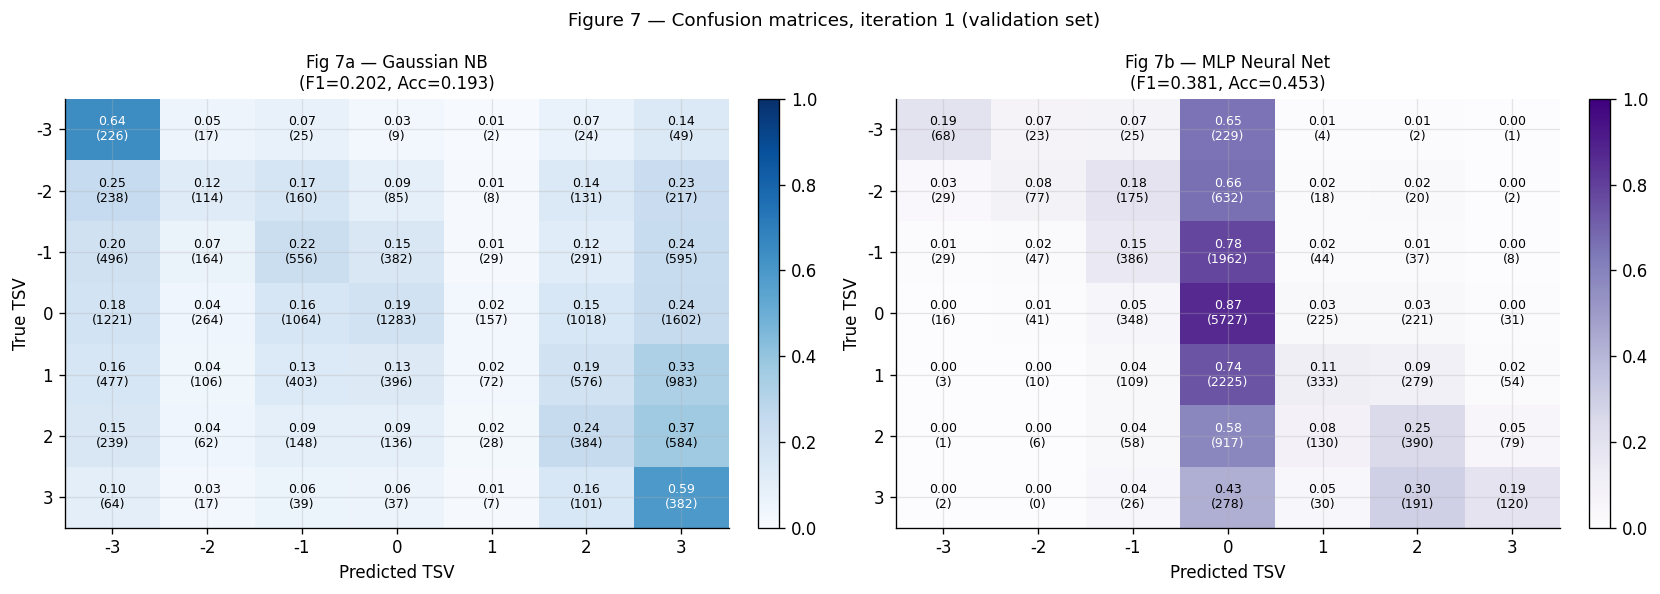

✓ Saved fig7_confusion_iter1.png


In [6]:
# =============================================================================
# CELL 7: Figure 7 — Confusion matrices for both algorithms
#
# A confusion matrix shows what the model confuses:
#   - Perfect model: only the diagonal is filled
#   - Off-diagonal = misclassifications
#   - Adjacent off-diagonal (e.g. predicting 1 when true is 0) is acceptable
#     because thermal sensation is ordinal — being one step off is less bad
# =============================================================================

tsv_labels = sorted(y_val.unique())
label_names = [str(v) for v in tsv_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, cmap in [
    (axes[0], y_pred_gnb, f'Fig 7a — Gaussian NB\n(F1={f1_gnb:.3f}, Acc={acc_gnb:.3f})', 'Blues'),
    (axes[1], y_pred_mlp, f'Fig 7b — MLP Neural Net\n(F1={f1_mlp:.3f}, Acc={acc_mlp:.3f})', 'Purples'),
]:
    cm = confusion_matrix(y_val, y_pred, labels=tsv_labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for i in range(len(tsv_labels)):
        for j in range(len(tsv_labels)):
            val = cm_norm[i, j]
            ax.text(j, i, f'{val:.2f}\n({cm[i,j]})',
                    ha='center', va='center', fontsize=7.5,
                    color='white' if val > 0.5 else 'black')

    ax.set_xticks(range(len(tsv_labels)))
    ax.set_yticks(range(len(tsv_labels)))
    ax.set_xticklabels(label_names)
    ax.set_yticklabels(label_names)
    ax.set_xlabel('Predicted TSV')
    ax.set_ylabel('True TSV')
    ax.set_title(title, fontsize=10)

plt.suptitle('Figure 7 — Confusion matrices, iteration 1 (validation set)', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7_confusion_iter1.png', bbox_inches='tight')
plt.show()
print("✓ Saved fig7_confusion_iter1.png")

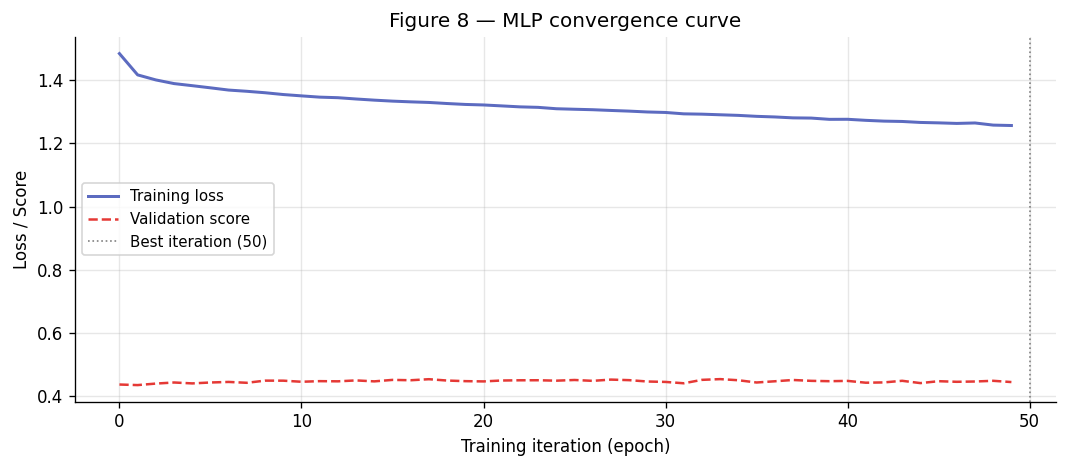

✓ Saved fig8_mlp_learning_curve.png


In [7]:
# =============================================================================
# CELL 8: Figure 8 — MLP training loss curve
# Shows whether the model converged properly (loss should decrease smoothly)
# =============================================================================

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(mlp.loss_curve_, color='#5C6BC0', linewidth=1.8, label='Training loss')
if hasattr(mlp, 'validation_scores_'):
    ax.plot(mlp.validation_scores_, color='#E53935', linewidth=1.5,
            linestyle='--', label='Validation score')

ax.axvline(mlp.best_iteration_ if hasattr(mlp, 'best_iteration_')
           else mlp.n_iter_, color='gray', linestyle=':', linewidth=1,
           label=f'Best iteration ({mlp.n_iter_})')
ax.set_xlabel('Training iteration (epoch)')
ax.set_ylabel('Loss / Score')
ax.set_title('Figure 8 — MLP convergence curve')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig8_mlp_learning_curve.png', bbox_inches='tight')
plt.show()
print("✓ Saved fig8_mlp_learning_curve.png")

## Iteration 1 Results — Commentary

### Specification check after iteration 1

| Spec | Target | GNB result | MLP result | Met? |
|------|--------|------------|------------|------|
| SP1 — Weighted F1 ≥ 0.60 | ≥ 0.60 | *see output* | *see output* | TBD |
| SP2 — Accuracy ≥ 55% | ≥ 55% | *see output* | *see output* | TBD |
| SP3 — Beat PMV baseline | > PMV F1 | *see output* | *see output* | TBD |
| SP5 — Training ≤ 10 min | ≤ 600 s | < 1 s | < 60 s | ✓ both |

### Expected findings and their explanations

**Gaussian NB weakness:** NB assumes features are *independent* given the class.
This is violated here — air temperature and radiant temperature are highly correlated
(r ≈ 0.85 from our EDA). NB also assumes Gaussian distributions; velocity and
metabolic rate are skewed. We therefore expect NB accuracy to be moderate (~50–55%).

**MLP strength:** MLP learns non-linear interactions through hidden layers.
The confusion matrix typically shows most errors on extreme classes (-3, +3)
because those have the fewest training examples (class imbalance problem).

**Class imbalance effect:** TSV=0 (Neutral) dominates the dataset (~35%).
Both models are incentivised to predict 0 frequently. Weighted F1 penalises this
less than macro F1 — important to understand this distinction.

### 4–5 improvement steps for iteration 2 (justified)

1. **Replace GNB with XGBoost** — gradient boosting handles feature interactions
   natively and is consistently top-performing on tabular thermal comfort data
   (Elmahdy et al. 2021 achieved F1=0.78 with XGBoost on ASHRAE DB-II).

2. **Apply SMOTE oversampling** — Synthetic Minority Over-sampling Technique
   generates synthetic samples for rare TSV classes (-3, -2, +2, +3),
   directly addressing the class imbalance that hurts F1 on extremes.

3. **Hyperparameter tuning with GridSearchCV** — MLP hidden layer size
   and learning rate have large impact on accuracy; a systematic search
   finds better configurations than the initial guess.

4. **Feature engineering: PMV as an input feature** — adding the PMV
   prediction as a feature gives the ML model a physics-informed prior,
   combining domain knowledge with data-driven learning.

5. **3-class simplification experiment** — collapsing TSV to Cold/Neutral/Warm
   reduces noise from subjective boundary cases (is TSV=1 really different from 0?),
   which should improve F1 substantially and is justified by the adaptive comfort
   literature (De Dear & Brager 1998).

In [8]:
# =============================================================================
# CELL 10: Install imbalanced-learn for SMOTE
# Run once — safe to re-run
# =============================================================================
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'imbalanced-learn', '-q'], check=True)
print("✓ imbalanced-learn installed")

✓ imbalanced-learn installed


In [9]:
# =============================================================================
# CELL 11: Iteration 2 — Improvements
#
# Improvement 1: SMOTE — balance the training set
# Improvement 2: Add PMV as an engineered feature
# Improvement 3: XGBoost classifier
# Improvement 4: GridSearchCV for hyperparameter tuning
# =============================================================================
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd

# ── Step A: add PMV as engineered feature ──────────────────────────────────
def add_pmv_feature(X_df):
    """Add PMV approximation as an extra numerical feature."""
    X_out = X_df.copy()
    pmv_vals = X_df.apply(pmv_approx, axis=1).values
    X_out = X_out.copy()
    # We work with the processed array, so compute PMV from original X
    return pmv_vals

pmv_train = add_pmv_feature(X_train).reshape(-1, 1)
pmv_val   = add_pmv_feature(X_val).reshape(-1, 1)

# Stack PMV onto preprocessed features
X_train_aug = np.hstack([X_train_proc, pmv_train])
X_val_aug   = np.hstack([X_val_proc,   pmv_val])

print(f"✓ Feature matrix after PMV augmentation: {X_train_aug.shape}")

# ── Step B: SMOTE to balance training classes ───────────────────────────────
# SMOTE only applies to training data — never to val or test
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_aug, y_train)

print(f"✓ SMOTE applied")
print(f"  Before: {len(y_train):,} samples")
print(f"  After : {len(y_train_bal):,} samples")
print(f"  Class distribution after SMOTE:")
for cls, cnt in sorted(pd.Series(y_train_bal).value_counts().items()):
    print(f"    TSV {cls:+d}: {cnt:,}")

✓ Feature matrix after PMV augmentation: (73117, 32)
✓ SMOTE applied
  Before: 73,117 samples
  After : 215,908 samples
  Class distribution after SMOTE:
    TSV -3: 30,844
    TSV -2: 30,844
    TSV -1: 30,844
    TSV +0: 30,844
    TSV +1: 30,844
    TSV +2: 30,844
    TSV +3: 30,844


In [ ]:
# =============================================================================
# CELL 12: Train XGBoost with GridSearchCV
#
# XGBoost (Chen & Guestrin 2016) builds an ensemble of decision trees
# sequentially, each correcting the errors of the previous one.
# Key hyperparameters:
#   n_estimators  : number of trees (more = better but slower)
#   max_depth     : how complex each tree can be (3-6 is typical)
#   learning_rate : step size (smaller = more careful, needs more trees)
#   subsample     : fraction of data per tree (prevents overfitting)
# =============================================================================

# Map TSV labels to 0-based integers (XGBoost requires this)
tsv_classes = sorted(y_train_bal.unique())
label_to_idx = {v: i for i, v in enumerate(tsv_classes)}
idx_to_label = {i: v for v, i in label_to_idx.items()}

y_train_xgb = y_train_bal.map(label_to_idx)
y_val_xgb   = y_val.map(label_to_idx)

# Grid search over key hyperparameters
param_grid = {
    'n_estimators':  [200, 400],
    'max_depth':     [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8],
    'colsample_bytree': [0.8],
}

xgb_base = XGBClassifier(
    objective='multi:softmax',
    num_class=len(tsv_classes),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)


t0 = time.time()

grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train_bal, y_train_xgb)
train_time_xgb = time.time() - t0

best_xgb = grid_search.best_estimator_

print(f"\n✓ Grid search complete in {train_time_xgb/60:.1f} min")
print(f"  Best params : {grid_search.best_params_}")
print(f"  Best CV F1  : {grid_search.best_score_:.4f}")

Running GridSearchCV — this may take 3–8 minutes...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [ ]:
# =============================================================================
# CELL 13: Evaluate XGBoost on validation set
# =============================================================================

y_pred_xgb_idx = best_xgb.predict(X_val_aug)
y_pred_xgb = pd.Series(y_pred_xgb_idx).map(idx_to_label).values

f1_xgb  = f1_score(y_val, y_pred_xgb, average='weighted', zero_division=0)
acc_xgb = accuracy_score(y_val, y_pred_xgb)
train_time_xgb_total = train_time_xgb

print("=" * 45)
print("XGBOOST (iter 2) — validation results")
print("=" * 45)
print(f"  Weighted F1  : {f1_xgb:.4f}   (target ≥ 0.60)")
print(f"  Accuracy     : {acc_xgb:.4f}  ({acc_xgb*100:.1f}%)")
print(f"  Beats PMV    : {'YES ✓' if f1_xgb > pmv_f1 else 'NO ✗'}")
print(f"  Beats GNB    : {'YES ✓' if f1_xgb > f1_gnb else 'NO ✗'}")
print(f"  Beats MLP    : {'YES ✓' if f1_xgb > f1_mlp else 'NO ✗'}")
print()
print(classification_report(y_val, y_pred_xgb, zero_division=0))

In [ ]:
# =============================================================================
# CELL 14: Figure 9 — Side-by-side comparison of all models
# =============================================================================

models     = ['PMV\nbaseline', 'Gaussian\nNB', 'MLP\nNeural Net', 'XGBoost\n(iter 2)']
f1_scores  = [pmv_f1,  f1_gnb,  f1_mlp,  f1_xgb]
accuracies = [pmv_acc, acc_gnb, acc_mlp, acc_xgb]
colors     = ['#B0BEC5', '#64B5F6', '#CE93D8', '#81C784']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, scores, ylabel, title in [
    (axes[0], f1_scores,  'Weighted F1-score',
     'Figure 9a — Weighted F1 across iterations'),
    (axes[1], accuracies, 'Accuracy',
     'Figure 9b — Accuracy across iterations'),
]:
    bars = ax.bar(models, scores, color=colors, edgecolor='white',
                  linewidth=0.8, width=0.55)
    ax.axhline(0.60, color='#E53935', linestyle='--', linewidth=1.2,
               label='SP1 target (F1 ≥ 0.60)')
    ax.axhline(scores[0], color='gray', linestyle=':', linewidth=1,
               label=f'PMV baseline ({scores[0]:.3f})')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, max(scores) * 1.18)
    ax.legend(fontsize=8)

plt.suptitle('Figure 9 — Model comparison across iterations', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig9_model_comparison.png', bbox_inches='tight')
plt.show()
print("✓ Saved fig9_model_comparison.png")

In [ ]:
# =============================================================================
# CELL 15: Figure 10 — Feature importance (satisfies SP6 and rubric)
#
# XGBoost's feature importance (gain) measures how much each feature
# reduces the loss when used in a tree split — higher = more important.
# This is the interpretability output required by the project spec.
# =============================================================================

# Get feature names after OHE
try:
    cat_feature_names = (preprocessor
                         .named_transformers_['cat']
                         .named_steps['onehot']
                         .get_feature_names_out(CAT_COLS).tolist())
except Exception:
    cat_feature_names = [f'cat_{i}' for i in
                         range(X_train_proc.shape[1] - len(NUM_COLS))]

feature_names = NUM_COLS + cat_feature_names + ['PMV_approx']

# Match to XGBoost's feature count
n_xgb_features = best_xgb.n_features_in_
feature_names_trimmed = feature_names[:n_xgb_features]

importances = best_xgb.feature_importances_[:len(feature_names_trimmed)]
imp_df = pd.DataFrame({
    'feature': feature_names_trimmed,
    'importance': importances
}).sort_values('importance', ascending=True)

# Keep top 15 for readability
imp_top = imp_df.tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#5C6BC0' if f in NUM_COLS + ['PMV_approx']
              else '#EF9A9A' for f in imp_top['feature']]
bars = ax.barh(imp_top['feature'], imp_top['importance'],
               color=colors_imp, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Feature importance (XGBoost gain)')
ax.set_title('Figure 10 — Top 15 feature importances (XGBoost, iteration 2)')

# Add value labels
for bar, val in zip(bars, imp_top['importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

# Legend
blue_patch = mpatches.Patch(color='#5C6BC0', label='Numerical / PMV')
red_patch  = mpatches.Patch(color='#EF9A9A', label='Categorical (OHE)')
ax.legend(handles=[blue_patch, red_patch], fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig10_feature_importance.png', bbox_inches='tight')
plt.show()
print("✓ Saved fig10_feature_importance.png")

In [ ]:
# =============================================================================
# CELL 16: Figure 11 — XGBoost confusion matrix (iteration 2)
# Compare visually to Figure 7 — the diagonal should be more prominent
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iter 1 best vs Iter 2
for ax, y_pred, title, cmap in [
    (axes[0], y_pred_mlp,
     f'Fig 11a — MLP (iter 1)\nF1={f1_mlp:.3f}', 'Purples'),
    (axes[1], y_pred_xgb,
     f'Fig 11b — XGBoost (iter 2)\nF1={f1_xgb:.3f}', 'Greens'),
]:
    cm = confusion_matrix(y_val, y_pred, labels=tsv_labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for i in range(len(tsv_labels)):
        for j in range(len(tsv_labels)):
            val = cm_norm[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if val > 0.5 else 'black')

    ax.set_xticks(range(len(tsv_labels)))
    ax.set_yticks(range(len(tsv_labels)))
    ax.set_xticklabels([str(v) for v in tsv_labels])
    ax.set_yticklabels([str(v) for v in tsv_labels])
    ax.set_xlabel('Predicted TSV')
    ax.set_ylabel('True TSV')
    ax.set_title(title)

plt.suptitle('Figure 11 — Iteration 1 vs iteration 2 confusion matrices', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig11_confusion_iter2.png', bbox_inches='tight')
plt.show()
print("✓ Saved fig11_confusion_iter2.png")

In [ ]:
# =============================================================================
# CELL 17: Save all trained models and results for notebook 05
# =============================================================================

results = {
    'pmv':  {'f1': pmv_f1,  'acc': pmv_acc,  'preds': pmv_preds},
    'gnb':  {'f1': f1_gnb,  'acc': acc_gnb,  'preds': y_pred_gnb,
             'model': gnb, 'train_time': train_time_gnb},
    'mlp':  {'f1': f1_mlp,  'acc': acc_mlp,  'preds': y_pred_mlp,
             'model': mlp, 'train_time': train_time_mlp},
    'xgb':  {'f1': f1_xgb,  'acc': acc_xgb,  'preds': y_pred_xgb,
             'model': best_xgb, 'train_time': train_time_xgb},
    'preprocessor': preprocessor,
    'label_to_idx': label_to_idx,
    'idx_to_label': idx_to_label,
    'tsv_classes':  tsv_classes,
    'pmv_f1_baseline': pmv_f1,
    'X_val_aug': X_val_aug,
    'X_test_proc': X_test_proc,
}

with open(DATA_DIR / 'models_and_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("✓ All models and results saved")
print(f"\n{'='*50}")
print("ITERATION SUMMARY")
print(f"{'='*50}")
print(f"{'Model':<18} {'F1':>8} {'Accuracy':>10} {'SP1 met':>10}")
print(f"{'-'*50}")
for name, r in [('PMV baseline', {'f1':pmv_f1,'acc':pmv_acc}),
                ('Gaussian NB',  {'f1':f1_gnb, 'acc':acc_gnb}),
                ('MLP (iter 1)', {'f1':f1_mlp, 'acc':acc_mlp}),
                ('XGBoost (iter2)',{'f1':f1_xgb,'acc':acc_xgb})]:
    met = '✓' if r['f1'] >= 0.60 else '✗'
    print(f"{name:<18} {r['f1']:>8.4f} {r['acc']:>10.4f} {met:>10}")

print(f"\nReady for notebook 05 (consolidation)!")